## Importing Libraries

In [51]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.lines import Line2D
import seaborn as sns

## Reading the data and preprocessing

In [8]:
# read the data from an excel file into a pandas dataframe
df = pd.read_excel('sales.xlsx')
df.head()
df.shape

(525461, 8)

In [9]:
# Deleting the rows with not available customer ID.
df_no_missing_CustomerId = df.copy()
df_no_missing_CustomerId = df_no_missing_CustomerId.dropna(subset=['CustomerId'])

# Deleting dublicates
df_no_duplicate = df_no_missing_CustomerId.copy()
df_no_duplicate = df_no_duplicate.drop_duplicates()

# Deleting the rows with Unit price less than or equal to zero.
df_no_missing_price = df_no_duplicate.copy()
df_no_missing_price = df_no_missing_price[df_no_missing_price['UnitPrice'] > 0]

# calculating the percentage of cancelled orders
unique_values = df_no_missing_price['InvoiceNumber'].drop_duplicates().tolist()
percentage_cancelled_orders = round(sum(1 for item in unique_values if isinstance(item, str))/len(unique_values) *100)

# Sorting the dataframe based on cancelling ratio and finding top cancelling customers
result = (
    df_no_missing_price
    .groupby('CustomerId')['InvoiceNumber']
    .agg(lambda x: (
        x.drop_duplicates().astype(str)
         .pipe(lambda s: s.str.startswith('C').sum())
    ))
    .reset_index(name='ratio_c')
).sort_values(by='ratio_c', ascending=False)


result['CustomerId'] = result['CustomerId'].astype(str)
top_cancelling_customers = result['CustomerId'].head(10).tolist()

# Deleting the cancelled invoices
df_no_canceled_invoice = df_no_missing_price.copy()

df_no_canceled_invoice = df_no_canceled_invoice[~df_no_canceled_invoice['InvoiceNumber'].astype(str).str.startswith('C')]
df_no_canceled_invoice['InvoiceNumber'] = df_no_canceled_invoice['InvoiceNumber'].astype(int)

# saving the preprocessed dataframe
df_no_canceled_invoice.to_csv("preprocessed_sales.csv", index=False)

## Data Insights & Visualization

In [10]:
# finding the period of orders
df = df_no_canceled_invoice.copy()
number_of_orders = len(df['InvoiceNumber'].drop_duplicates())
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
window_period = (str(df['InvoiceDate'].min()), str(df['InvoiceDate'].max()))
window_period

('2009-12-01 07:45:00', '2010-12-09 20:01:00')

### Distribution of Orders by Day of Week

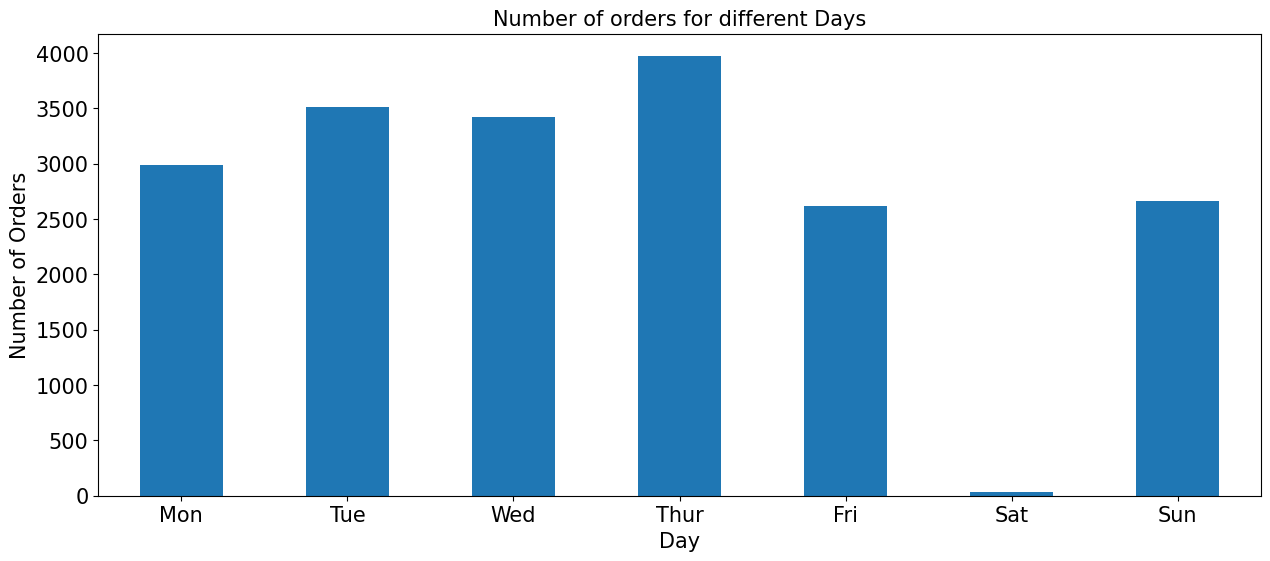

In [11]:
# barplot for number of orders in different days of the week

df['weekday'] = df['InvoiceDate'].dt.weekday
result = (
    df
    .groupby('weekday')['InvoiceNumber']
    .agg(lambda x: len(x.drop_duplicates()))
    .reset_index(name='count')
    .sort_values(by='weekday')
)

result = pd.Series(result['count'].values, index=['Mon', 'Tue', 'Wed', 'Thur', 'Fri', 'Sat', 'Sun'])
result

fig1, ax1 = plt.subplots()
fig1.set_size_inches(15,6)
result.plot(kind='bar', ax=ax1)
ax1.set_title("Number of orders for different Days", fontsize=15)
ax1.set_xlabel("Day", fontsize=15)
ax1.set_ylabel("Number of Orders", fontsize=15)
ax1.tick_params(axis='x', labelsize=15, rotation=0)
ax1.tick_params(axis='y', labelsize=15)

plt.show()

### Distribution of Orders by Month of Year

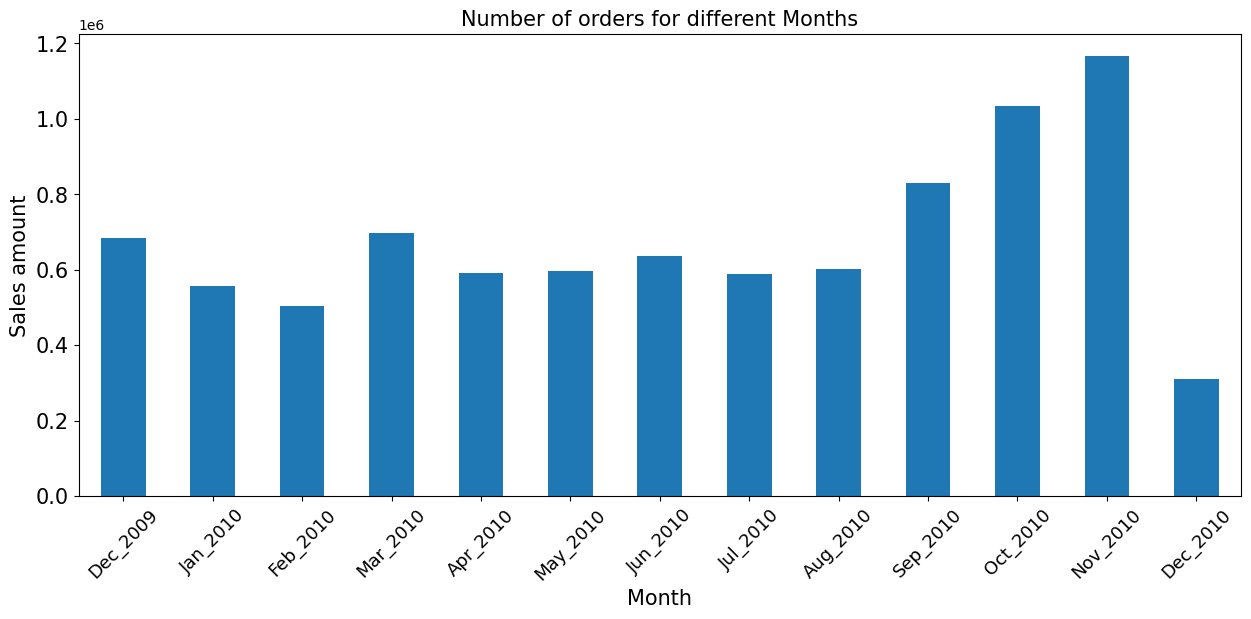

In [12]:
# bar plot for number of orders in different months of the year

df['month'] = df['InvoiceDate'].dt.strftime('%b_%Y')
df['sale'] = df['UnitPrice'] * df['Quantity']

result = (
    df
    .groupby('month')['sale'].sum()
)
result.index = pd.to_datetime(result.index, format='%b_%Y')
result = result.sort_index()
result.index = result.index.strftime('%b_%Y')
fig2, ax2 = plt.subplots()
fig2.set_size_inches(15,6)
result.plot(kind='bar', ax=ax2)
ax2.set_title("Number of orders for different Months", fontsize=15)
ax2.set_xlabel("Month", fontsize=15)
ax2.set_ylabel("Sales amount", fontsize=15)
ax2.tick_params(axis='x', labelsize=13, rotation=45)
ax2.tick_params(axis='y', labelsize=15)

plt.show()

In [13]:
### Country Segmentation and Scatter Plot Visualization

In [14]:
# preparing the dataframe for creating a scatter plot. In this part of the code, we visualize different countries
# on a scatter plot based on their sales volume and number of customers.

df.drop(df[df['Country'] == 'United Kingdom'].index, inplace=True)
df['sale'] = df['UnitPrice'] * df['Quantity']

result = (df.groupby('Country').agg(invoice=('CustomerId', lambda x: len(x.drop_duplicates())),sale=('sale', 'sum'))
    .reset_index()
)

qSA = result['sale'].quantile(0.75)
qCC = result['invoice'].quantile(0.75)

# Divided the countries into four groups according to these two metrics, and assign colors to the data points
# based on their group.
# 1- Highest customer & revenue: red
# 2- High customer & low revenue: blue
# 3- High revenue & low customer: green
# 4- Low customer & revenue: yellow

def assign_color(row):
    cond_invoice = row['invoice'] > qCC
    cond_sale = row['sale'] > qSA
    
    if cond_invoice and cond_sale:
        return 'red'
    elif cond_invoice and not cond_sale:
        return 'blue'
    elif not cond_invoice and cond_sale:
        return 'green'
    else:
        return 'yellow'

result['color'] = result.apply(assign_color, axis=1)


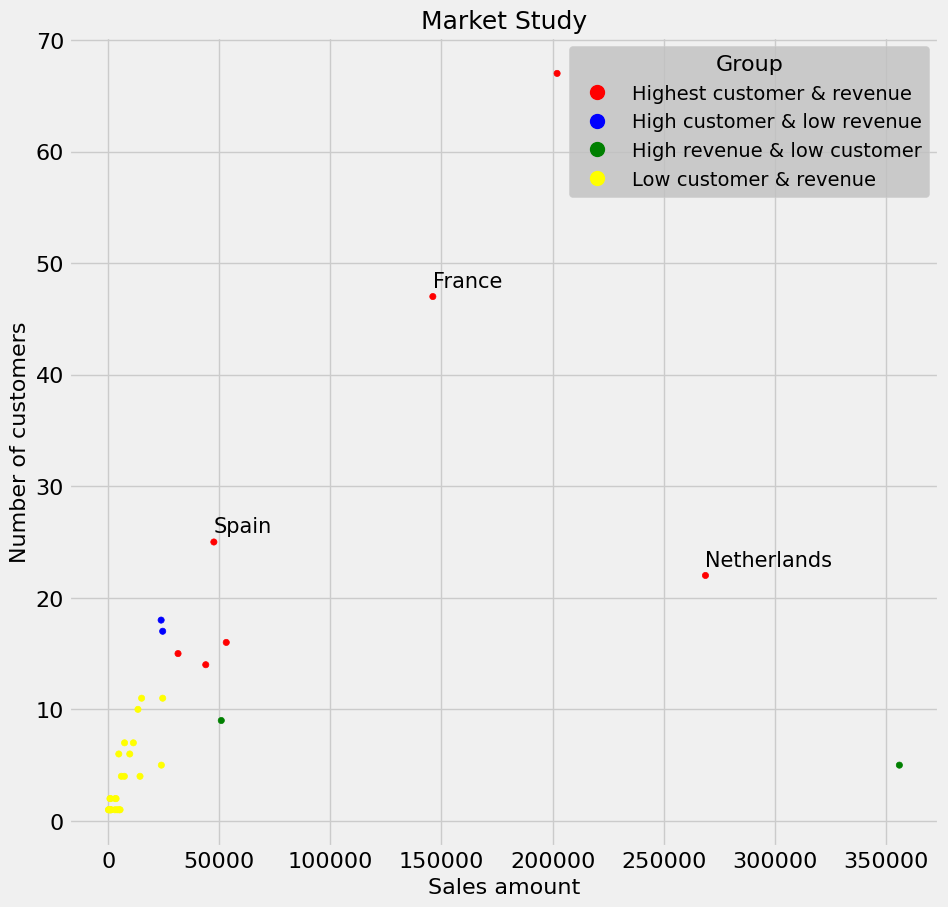

In [15]:
# plotting the scatter plot
plt.style.use('fivethirtyeight')
fig, ax = plt.subplots(figsize=(10, 10))

result['sale'] = result['sale'].round(2)

scatter = ax.scatter(x=result['sale'],y=result['invoice'],c=result['color'],s=20)


countries_to_label = ['France', 'Spain', 'Netherlands']
for country in countries_to_label:
    row = result[result['Country'] == country].iloc[0]
    ax.text(row['sale'],row['invoice'] + 0.5,row['Country'],fontsize=15,ha='left',va='bottom')

legend_labels = {
    'red': 'Highest customer & revenue',
    'blue': 'High customer & low revenue',
    'green': 'High revenue & low customer',
    'yellow' : 'Low customer & revenue'
}

handles = [
    Line2D([0], [0], marker='o', linestyle='', markerfacecolor=color, markeredgecolor=color, markersize=10)
    for color in legend_labels.keys()
]

ax.legend(
    handles=handles,
    labels=legend_labels.values(),
    title='Group',
    title_fontsize=16,
    fontsize=14,
    frameon=True,
    facecolor='silver',
    loc='upper right'
)


ax.set_title('Market Study', fontsize=18)
ax.set_xlabel('Sales amount', fontsize=16)
ax.set_ylabel('Number of customers', fontsize=16)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)
plt.show()

## Metrics Calculation

### Recency

In [16]:
# Calculating recency metric for each customer which is: The number of days since a user’s last purchase, calculated
# relative to one day after the most recent date available in the dataset.
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
last_day = df['InvoiceDate'].max() + pd.Timedelta(days=1)

df_customer_segments = (
    df
    .groupby('CustomerId')['InvoiceDate']
    .agg(lambda x: (last_day - x.max()).days)
    .reset_index()
    .rename(columns={'InvoiceDate':'Recency'})
    .sort_values(by = 'CustomerId')
    
)

### Frequency

In [17]:
# Calculating the frequency metric for each customer.

tmp = (
    df
    .groupby('CustomerId')['InvoiceNumber']
    .agg(lambda x: len(x.drop_duplicates()))
    .reset_index()
    .sort_values(by = 'CustomerId')
    
)
df_customer_segments['Frequency'] = tmp['InvoiceNumber']

### Monetary value

In [18]:
# Calculating the monetary value for each customer

df['sale'] = df['UnitPrice'] * df['Quantity']
tmp = (
    df
    .groupby('CustomerId')['sale']
    .sum()
    .reset_index()
    .sort_values(by = 'CustomerId')
    
)
df_customer_segments['MonetaryValue'] = tmp['sale']

### Quartile-based Segmentation

In [19]:
# In this section, each of the three metrics is divided into four groups based on quartiles (Q1, Q2, Q3):
# Group 1 includes values less than or equal to Q1
# Group 2 includes values between Q1 and Q2
# Group 3 includes values between Q2 and Q3
# Group 4 includes values greater than Q3
#
# The results are stored in three new columns: F_quartile, R_quartile, and M_quartile,
# where each value represents the corresponding group number (from 1 to 4).

quartiles = df_customer_segments[['Recency', 'Frequency', 'MonetaryValue']].quantile([0.25, 0.5, 0.75]).rename(index={0.25:'Q1', 0.5:'Q2', 0.75:'Q3'})

def score(value, col):
    if value <= quartiles.loc['Q1', col]:
        return 1
    elif value <= quartiles.loc['Q2', col]:
        return 2
    elif value <= quartiles.loc['Q3', col]:
        return 3
    else:
        return 4
df_customer_segments['R_quartile'] = df_customer_segments['Recency'].apply(lambda x: score(x, 'Recency'))
df_customer_segments['F_quartile'] = df_customer_segments['Frequency'].apply(lambda x: score(x, 'Frequency'))
df_customer_segments['M_quartile'] = df_customer_segments['MonetaryValue'].apply(lambda x: score(x, 'MonetaryValue'))
df_customer_segments.head()

,CustomerId,Recency,Frequency,MonetaryValue,R_quartile,F_quartile,M_quartile
0,12347.0,2,2,1323.32,1,2,3
1,12348.0,73,1,222.16,3,1,1
2,12349.0,43,3,2671.14,2,3,4
3,12351.0,10,1,300.93,1,1,1
4,12352.0,11,2,343.80,1,2,1


### RFM Customer Segmentation

In [20]:
# Calculating RFM metric by using [R_quartile, F_quartile, M_quartile]
df_customer_segments['RFM'] = df_customer_segments['R_quartile']*100 + df_customer_segments['F_quartile'] * 10 + df_customer_segments['M_quartile']
# In this section, customers are segmented based on their RFM values according to the table below,
# and the segment names are stored in a column called 'Segment'.
# Note: 'X' represents any value (e.g., 14X includes 141, 142, 143, 144).
#
# Segment definitions:
# Best: 144
# AlmostLost: 344
# LostBigSpenders: 444
# LostCheap: 441
# Loyal: X4X
# BigSpenders: XX4
#
# Customers who do not match any of the defined segments are labeled as 'Normal'.
# If an RFM value matches multiple segments, priority is given to the segment
# that appears earlier in the table.

df_customer_segments['RFM'] = df_customer_segments['RFM'].astype(str)

def assign_segment(rfm):
    if rfm == '144':
        return 'Best'
    elif rfm == '344':
        return 'AlmostLost'
    elif rfm == '444':
        return 'LostBigSpenders'
    elif rfm == '441':
        return 'LostCheap'
    elif rfm[1] == '4':
        return 'Loyal'
    elif rfm[2] == '4':
        return 'BigSpenders'
    else:
        return 'Normal'

df_customer_segments['Segment'] = df_customer_segments['RFM'].apply(assign_segment)
df_customer_segments.head()

,CustomerId,Recency,Frequency,MonetaryValue,R_quartile,F_quartile,M_quartile,RFM,Segment
0,12347.0,2,2,1323.32,1,2,3,123,Normal
1,12348.0,73,1,222.16,3,1,1,311,Normal
2,12349.0,43,3,2671.14,2,3,4,234,BigSpenders
3,12351.0,10,1,300.93,1,1,1,111,Normal
4,12352.0,11,2,343.80,1,2,1,121,Normal


## Customer Retention Analysis (Cohort View)

In [21]:
# In this step, a retention-style plot is created to analyze customer behavior over time.
# The vertical axis represents the month in which each customer made their first purchase.
# The horizontal axis shows the percentage of those customers who remained active
# in the following months, meaning they made at least one invoice after their initial transaction.

# Convert invoice date to datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Extract month-level cohort start date
df['month_start'] = df['InvoiceDate'].dt.strftime('%Y-%m-01')

# Create customer-month interaction matrix (1 = purchase, 0 = no purchase)
result = (df.assign(value=1)
    .pivot_table(index='CustomerId', columns='month_start', values='value', fill_value=0)
    .reset_index()
    .sort_values(by='CustomerId')
)

# Identify first active month for each customer
columns = result.columns[1:]
result['first_one_idx'] = result[columns].values.argmax(axis=1)

# Compute cohort-wise retention percentages
final_result = (result.groupby('first_one_idx')[columns].mean()) * 100

# Shift retention values to align cohorts and pad with zeros
shifted_df = final_result.apply(
    lambda row: pd.Series(np.concatenate([row[row != 0].values,
                                          np.zeros((row == 0).sum())])),
    axis=1
)

# Clean and format final output
mask = shifted_df == 0
shifted_df.index.name = None
shifted_df = shifted_df.round(2)
shifted_df = shifted_df.replace(0, np.nan)

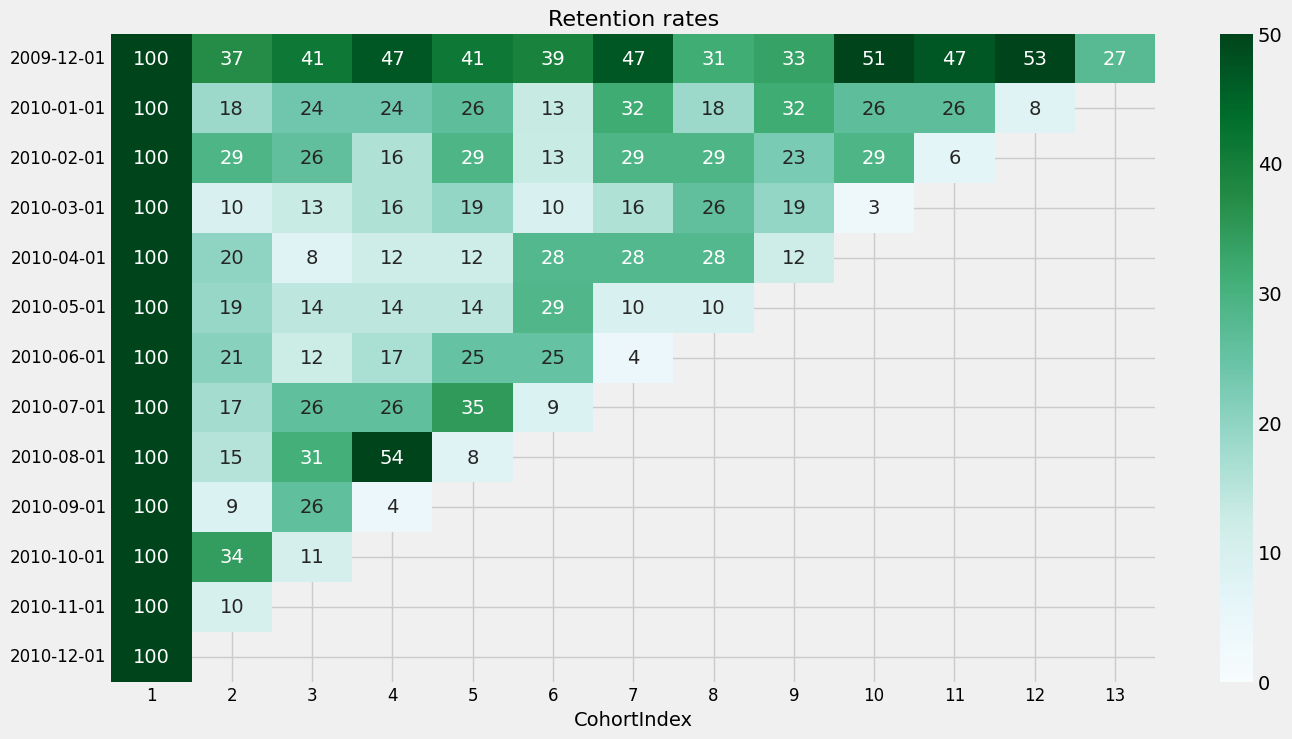

In [22]:
# Plotting the heatmap
fig, ax = plt.subplots(figsize=(15, 8))
sns.heatmap(
    shifted_df,
    mask=mask,
    annot=True,
    fmt='.0f',
    cmap='BuGn',
    vmin=0, vmax=50,
    ax=ax
)
ax.set_title('Retention rates', fontsize=16)
ax.set_xlabel('CohortIndex',fontsize=14)
ax.set_xticklabels(range(1, 14), rotation=0, fontsize=12)
ax.set_yticklabels(final_result.columns, rotation=0, fontsize=12)
plt.show()